# Finlora Fraud Risk-Scoring: Full Exploratory Data Analysis

Second deliverable in the pipeline: a column-by-column EDA of the cleaned/merged
dataset (`Data/finlora_cleaned_merged.csv`, produced by `notebooks/cleaned_data.ipynb`),
with every column's own distribution and its relationship to the target,
`is_fraud`.

**Contents**
1. Load data
2. Target variable
3. Identifier / high-cardinality columns (profiled, not modeled)
4. Categorical columns vs. target
5. `status`: a leakage warning, not a feature
6. Numeric columns vs. target
7. Data-quality flag vs. target
8. Time-based view
9. Correlation matrix
10. Summary of findings


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

sns.set_theme(style="whitegrid", rc={
    "font.size": 12, "axes.titlesize": 16, "axes.labelsize": 13,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 12,
    "axes.titleweight": "bold",
})
pd.set_option("display.max_columns", None)

# Bold, high-saturation palette used throughout
LEGIT, FRAUD = "#2A6FDB", "#E63946"
ACCENT, ACCENT2 = "#00A896", "#F4A300"
NEUTRAL = "#3D3D3D"
DIVERGING_CMAP = LinearSegmentedColormap.from_list("finlora_bold", [LEGIT, "#F5F1EC", FRAUD])

## 1. Load data

In [2]:
df = pd.read_csv("../Data/finlora_cleaned_merged.csv")
print("shape:", df.shape)
df.head()

shape: (126000, 28)


,transaction_id,account_id,account_type,kyc_tier,timestamp,day_of_week,hour_of_day,description,merchant_name,merchant_category,channel,amount,currency,amount_to_avg_ratio,avg_transaction_amount_30d,transaction_velocity_1h,transaction_country,home_country,is_cross_border,device_id,is_new_device,account_age_days,status,is_fraud,account_holder_name,account_created_date,personal_spend_baseline_usd,has_invalid_amount
0,FLR250216186265,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-02-16 14:55:35,Sunday,14,CNP PURCHASE - BOLT,Bolt,Travel,Card Not Present,84233.00,NGN,9.21,9143.33,0,NG,NG,0,NoDevice,-1,903,Completed,0,Amaka Okafor,2022-08-28,63.23,False
1,FLR250423143305,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-04-23 13:35:40,Wednesday,13,WEB PURCHASE - SLACK,Slack,Subscription/SaaS,Web Dashboard,9143.33,NGN,1.00,9143.33,0,NG,NG,0,NoDevice,-1,969,Declined,0,Amaka Okafor,2022-08-28,63.23,False
2,FLR250424154897,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-04-24 12:30:34,Thursday,12,MOBILE PURCHASE - JUSTRITE SUPERSTORE,Justrite Superstore,Groceries,Mobile App,20639.00,NGN,2.26,9143.33,0,NG,NG,0,DEV-9055235108,0,970,Completed,0,Amaka Okafor,2022-08-28,63.23,False
3,FLR250428101772,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-04-28 14:41:59,Monday,14,CNP PURCHASE - ADOBE CREATIVE CLOUD,Adobe Creative Cloud,Subscription/SaaS,Card Not Present,3177.43,NGN,0.21,14891.16,0,NG,NG,0,NoDevice,-1,974,Completed,0,Amaka Okafor,2022-08-28,63.23,False
4,FLR250628102827,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-06-28 16:15:47,Saturday,16,MOBILE PURCHASE - APPLE STORE,Apple Store,Electronics,Mobile App,97839.52,NGN,1.97,49609.59,0,NG,NG,0,DEV-9055235108,0,1035,Declined,0,Amaka Okafor,2022-08-28,63.23,False


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 126000 entries, 0 to 125999
Data columns (total 28 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   transaction_id               126000 non-null  str    
 1   account_id                   126000 non-null  str    
 2   account_type                 126000 non-null  str    
 3   kyc_tier                     126000 non-null  str    
 4   timestamp                    126000 non-null  str    
 5   day_of_week                  126000 non-null  str    
 6   hour_of_day                  126000 non-null  int64  
 7   description                  126000 non-null  str    
 8   merchant_name                126000 non-null  str    
 9   merchant_category            126000 non-null  str    
 10  channel                      126000 non-null  str    
 11  amount                       126000 non-null  float64
 12  currency                     126000 non-null  str    
 13  amount_to_

## 2. Target variable

`is_fraud` is the label the models are trained to predict: 1 if the transaction
was fraudulent, 0 otherwise.

is_fraud
0    122648
1      3352
Name: count, dtype: int64
Overall fraud rate: 2.6603%


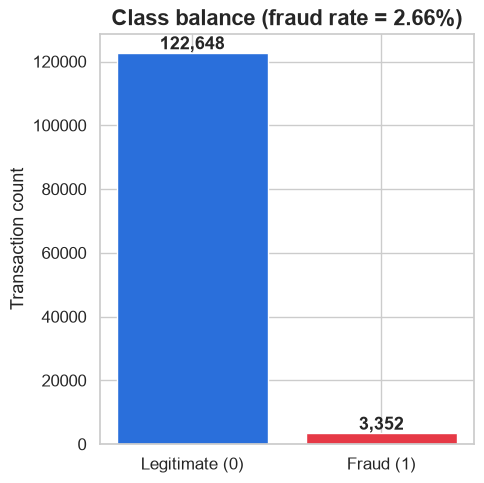

In [4]:
fraud_counts = df["is_fraud"].value_counts().sort_index()
fraud_rate = df["is_fraud"].mean()
print(fraud_counts)
print(f"Overall fraud rate: {fraud_rate:.4%}")

fig, ax = plt.subplots(figsize=(5, 5))
bars = ax.bar(["Legitimate (0)", "Fraud (1)"], fraud_counts.values, color=[LEGIT, FRAUD])
for bar, v in zip(bars, fraud_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{v:,}",
            ha="center", va="bottom", fontweight="bold", fontsize=13)
ax.set_title(f"Class balance (fraud rate = {fraud_rate:.2%})")
ax.set_ylabel("Transaction count")
ax.tick_params(labelsize=12)
plt.tight_layout()
plt.show()

**Finding:** the target is heavily imbalanced -- 3,352 of 126,000 transactions
(2.66%) are fraud. Accuracy is not a meaningful metric on data like this; every
comparison below reads fraud rate / distribution shape, not raw counts.

## 3. Identifier / high-cardinality columns

These columns exist to identify a record, not to describe it, so they carry no
generalizable fraud signal and are excluded from modeling -- profiled here for
completeness rather than plotted against the target.

| Column | Unique values | Role |
|---|---|---|
| `transaction_id` | 126,000 (all unique) | primary key |
| `account_id` | 7,144 | foreign key to the accounts table |
| `account_holder_name` | 1,000 | free text, one per holder |
| `description` | 8,644 | free-text transaction memo |
| `account_created_date` | 1,441 | redundant with `account_age_days` |
| `timestamp` | 125,758 | raw event time -- see Section 8 for the derived monthly view |
| `device_id` | 14,932 (+ `"NoDevice"`) | too fine-grained on its own; its *presence* is already captured by `is_new_device` (Section 4) |

In [5]:
for col in ["transaction_id", "account_id", "account_holder_name", "description", "account_created_date", "device_id"]:
    print(f"{col}: {df[col].nunique():,} unique values")

transaction_id: 126,000 unique values


account_id: 7,144 unique values
account_holder_name: 1,000 unique values
description: 8,644 unique values
account_created_date: 1,441 unique values
device_id: 14,932 unique values


## 4. Categorical columns vs. target

A reusable helper: fraud rate by category, sorted descending, with the overall
rate as a reference line. Bars at or above the overall rate are drawn in bold
red, bars below in bold blue -- color encodes "hotter/colder than baseline",
not an arbitrary category order.

In [6]:
def plot_fraud_rate(col, ax, top_n=None, min_count=0):
    grp = df.groupby(col)["is_fraud"].agg(["mean", "count"]).rename(columns={"mean": "fraud_rate"})
    grp = grp[grp["count"] >= min_count].sort_values("fraud_rate", ascending=False)
    if top_n:
        grp = grp.head(top_n)
    colors = [FRAUD if v >= fraud_rate else LEGIT for v in grp["fraud_rate"].values]
    ax.barh(grp.index.astype(str), grp["fraud_rate"].values, color=colors)
    ax.axvline(fraud_rate, color="black", linestyle="--", linewidth=1.5, label=f"overall rate ({fraud_rate:.2%})")
    ax.invert_yaxis()
    ax.set_xlabel("Fraud rate")
    ax.tick_params(labelsize=12)
    ax.legend(fontsize=11, loc="lower right")
    return grp

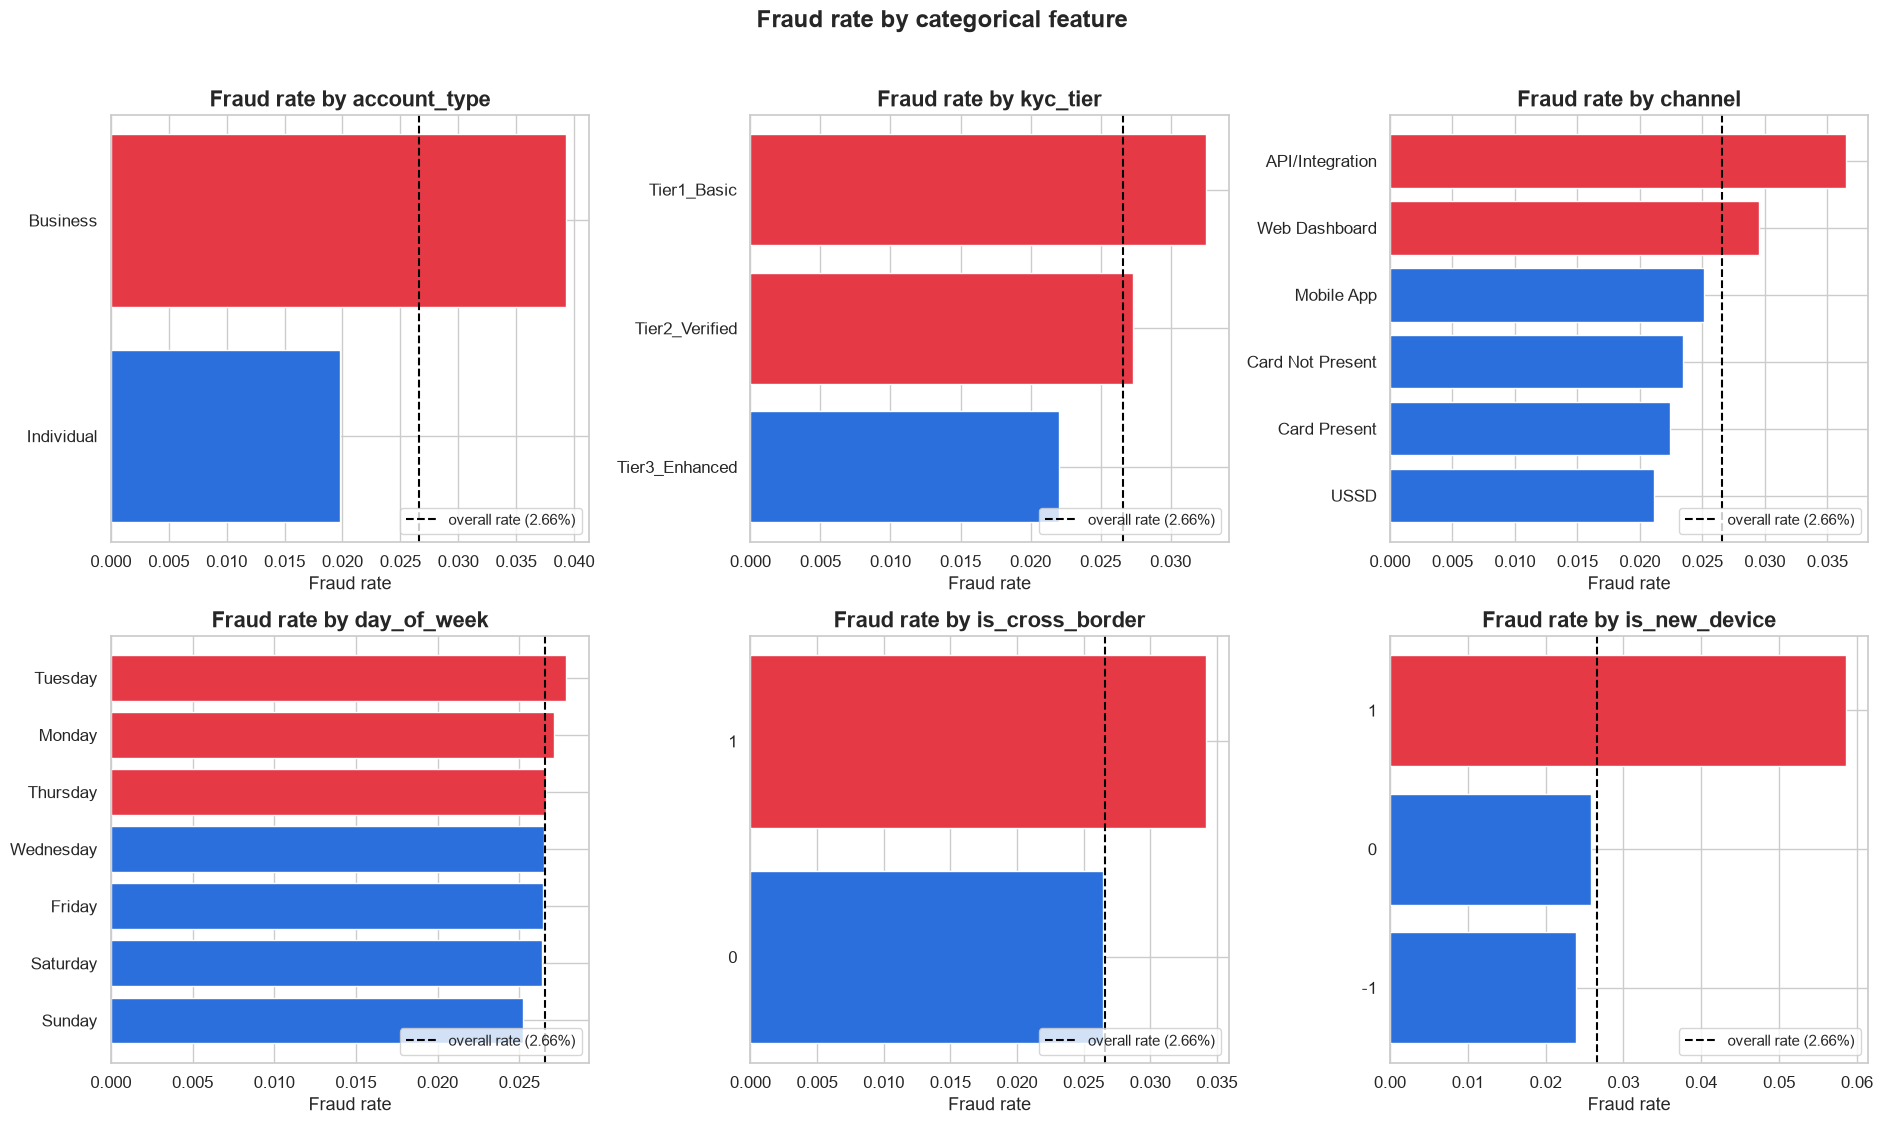

In [7]:
cat_cols = ["account_type", "kyc_tier", "channel", "day_of_week", "is_cross_border", "is_new_device"]

fig, axes = plt.subplots(2, 3, figsize=(19, 11))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    plot_fraud_rate(col, ax)
    ax.set_title(f"Fraud rate by {col}")

fig.suptitle("Fraud rate by categorical feature", fontweight="bold", fontsize=17, y=1.02)
plt.tight_layout()
plt.show()

**Findings:**
- `account_type`: **Business accounts (3.94%)** run roughly double the fraud rate of Individual accounts (1.98%).
- `kyc_tier` falls monotonically as verification increases -- Tier1_Basic (3.25%) to Tier3_Enhanced (2.20%) -- a genuine, ordered risk signal.
- `channel`: API/Integration (3.65%) and Web Dashboard (2.95%) run hotter than in-person or USSD channels.
- `is_cross_border` and `is_new_device` both roughly double the fraud rate when true (2.64% -> 3.42% and 2.58% -> 5.85% respectively) -- `is_new_device` is one of the strongest categorical splits in the dataset.
- `day_of_week` is nearly flat (2.52%-2.79%) -- a weak signal on its own.

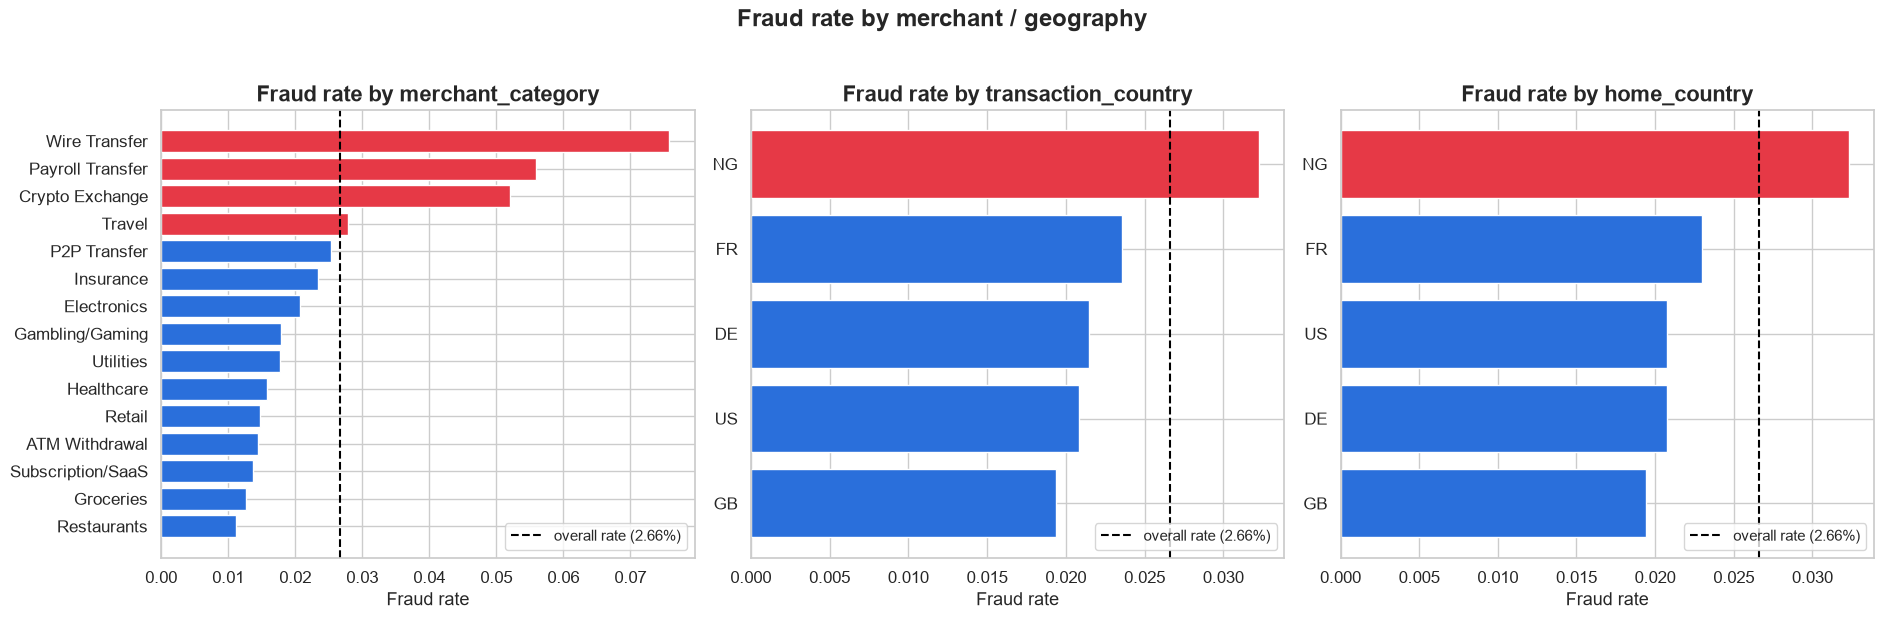

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6))

for ax, col in zip(axes, ["merchant_category", "transaction_country", "home_country"]):
    plot_fraud_rate(col, ax)
    ax.set_title(f"Fraud rate by {col}")

fig.suptitle("Fraud rate by merchant / geography", fontweight="bold", fontsize=17, y=1.03)
plt.tight_layout()
plt.show()

**Findings:**
- `merchant_category` has by far the widest spread of any categorical feature: **Wire Transfer (7.58%)** and Crypto Exchange (5.20%) run 5-7x hotter than Restaurants (1.12%) or Groceries (1.26%).
- `transaction_country` / `home_country` show a much narrower spread -- **NG runs mildly hotter (~3.2%)** than the other four countries (all 1.9%-2.4%) -- a real but modest lift, nowhere near the merchant-category spread above.

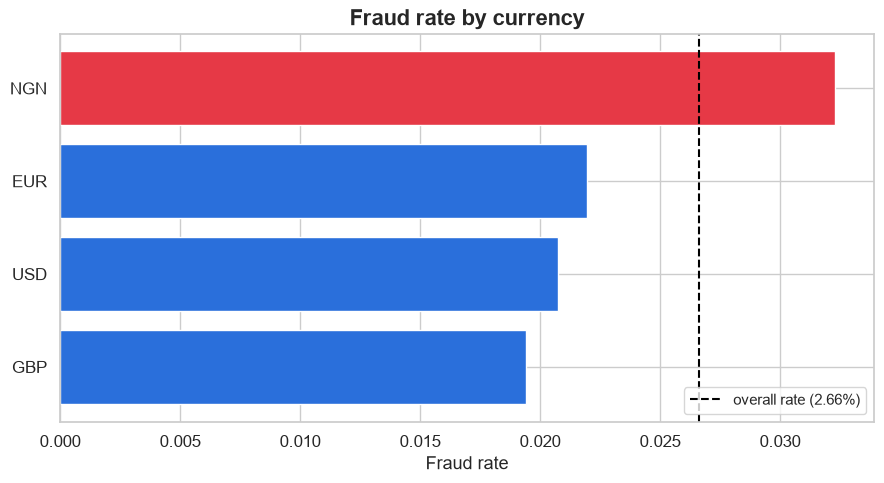

,fraud_rate,count
currency,,
NGN,0.032297,64185
EUR,0.021951,17949
USD,0.020763,24900
GBP,0.019403,18966


In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
grp = plot_fraud_rate("currency", ax)
ax.set_title("Fraud rate by currency")
plt.tight_layout()
plt.show()
grp

**Finding:** `currency` tracks `home_country` almost one-to-one (NGN/NG, USD/US, GBP/GB, EUR/FR+DE), so it carries no independent signal beyond what geography already shows.

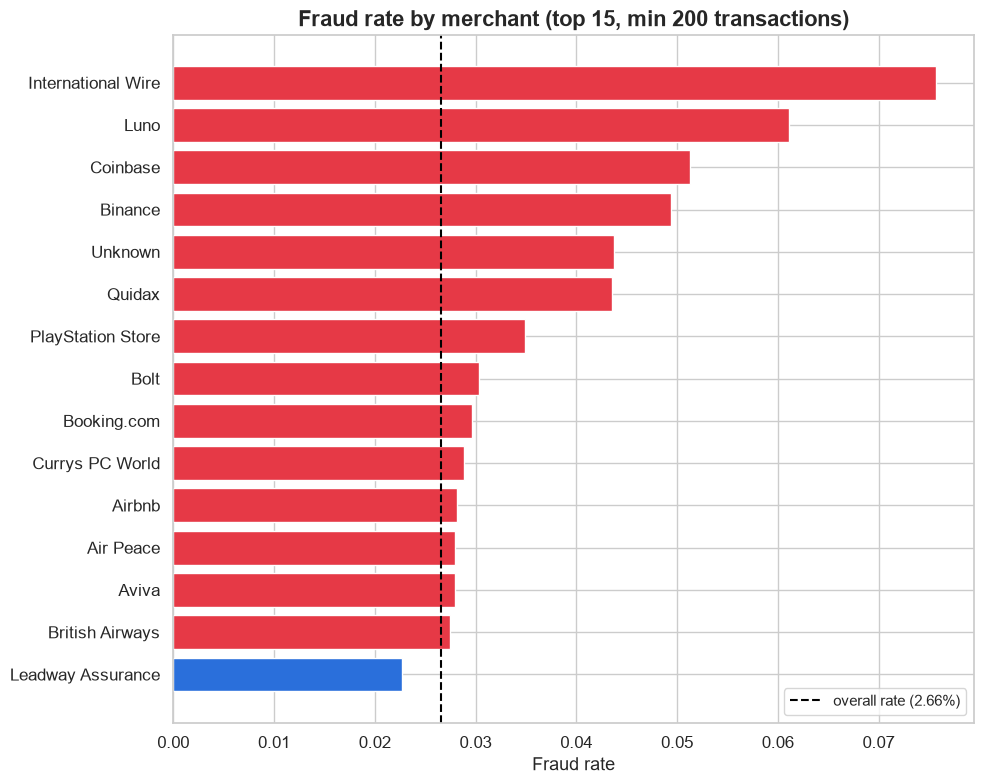

,fraud_rate,count
merchant_name,,
International Wire,0.075686,7584
Luno,0.061069,393
Coinbase,0.051282,429
Binance,0.049356,466
Unknown,0.043726,28610
Quidax,0.043590,390
PlayStation Store,0.034934,229
Bolt,0.030303,1254
Booking.com,0.029695,1246


In [10]:
fig, ax = plt.subplots(figsize=(10, 8))
grp = plot_fraud_rate("merchant_name", ax, top_n=15, min_count=200)
ax.set_title("Fraud rate by merchant (top 15, min 200 transactions)")
plt.tight_layout()
plt.show()
grp

**Finding:** at the individual-merchant level (filtered to merchants with at least 200 transactions, to avoid noisy rates from tiny samples), the ranking mirrors the `merchant_category` finding above -- wire-transfer and crypto-exchange merchants cluster at the top.

## 5. `status`: a leakage warning, not a feature

`status` (`Completed` / `Declined` / `Reversed`) looks like an ordinary transaction
attribute, but a `Reversed` status is frequently the *consequence* of fraud being
confirmed later (e.g. a chargeback) -- not something known at the moment a
transaction needs a risk score. Training on it would let a model see part of the
answer. It is shown here once, as a diagnostic, and then excluded from any
feature set used for modeling.

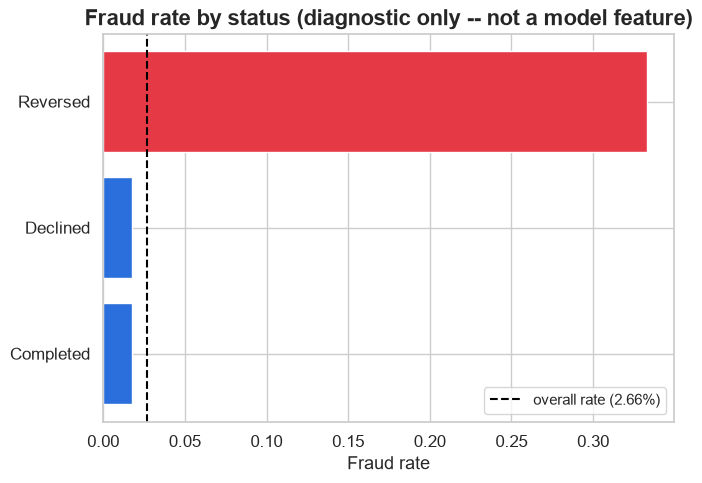

,fraud_rate,count
status,,
Reversed,0.332879,3668
Declined,0.017587,5629
Completed,0.017412,116703


In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
grp = plot_fraud_rate("status", ax)
ax.set_title("Fraud rate by status (diagnostic only -- not a model feature)")
plt.tight_layout()
plt.show()
grp

**Finding:** fraud rate is essentially flat between `Completed` (1.74%) and `Declined` (1.76%), but jumps to **33.29%** for `Reversed` -- confirming `status` must be excluded from the feature set.

## 6. Numeric columns vs. target

Box plots (median, IQR, whiskers, outliers) rather than a single summary bar --
a bar hides how much the two classes' distributions actually overlap. The
amount/ratio fields are heavily right-skewed, so those panels use a **log
y-axis** (rows with a non-positive value are excluded from those panels only --
`amount`/`avg_transaction_amount_30d` have a small number of negative values,
flagged as `has_invalid_amount` in the cleaning notebook, see Section 7).
`account_age_days` and `hour_of_day` stay on a linear axis since neither is
skewed the same way. `transaction_velocity_1h` is 0 for 99.9%/62% of
legit/fraud rows, so a box plot for it would be a flat line at zero -- that
panel instead shows the share of transactions with a repeat transaction in the
prior hour, which is where its real signal lives.

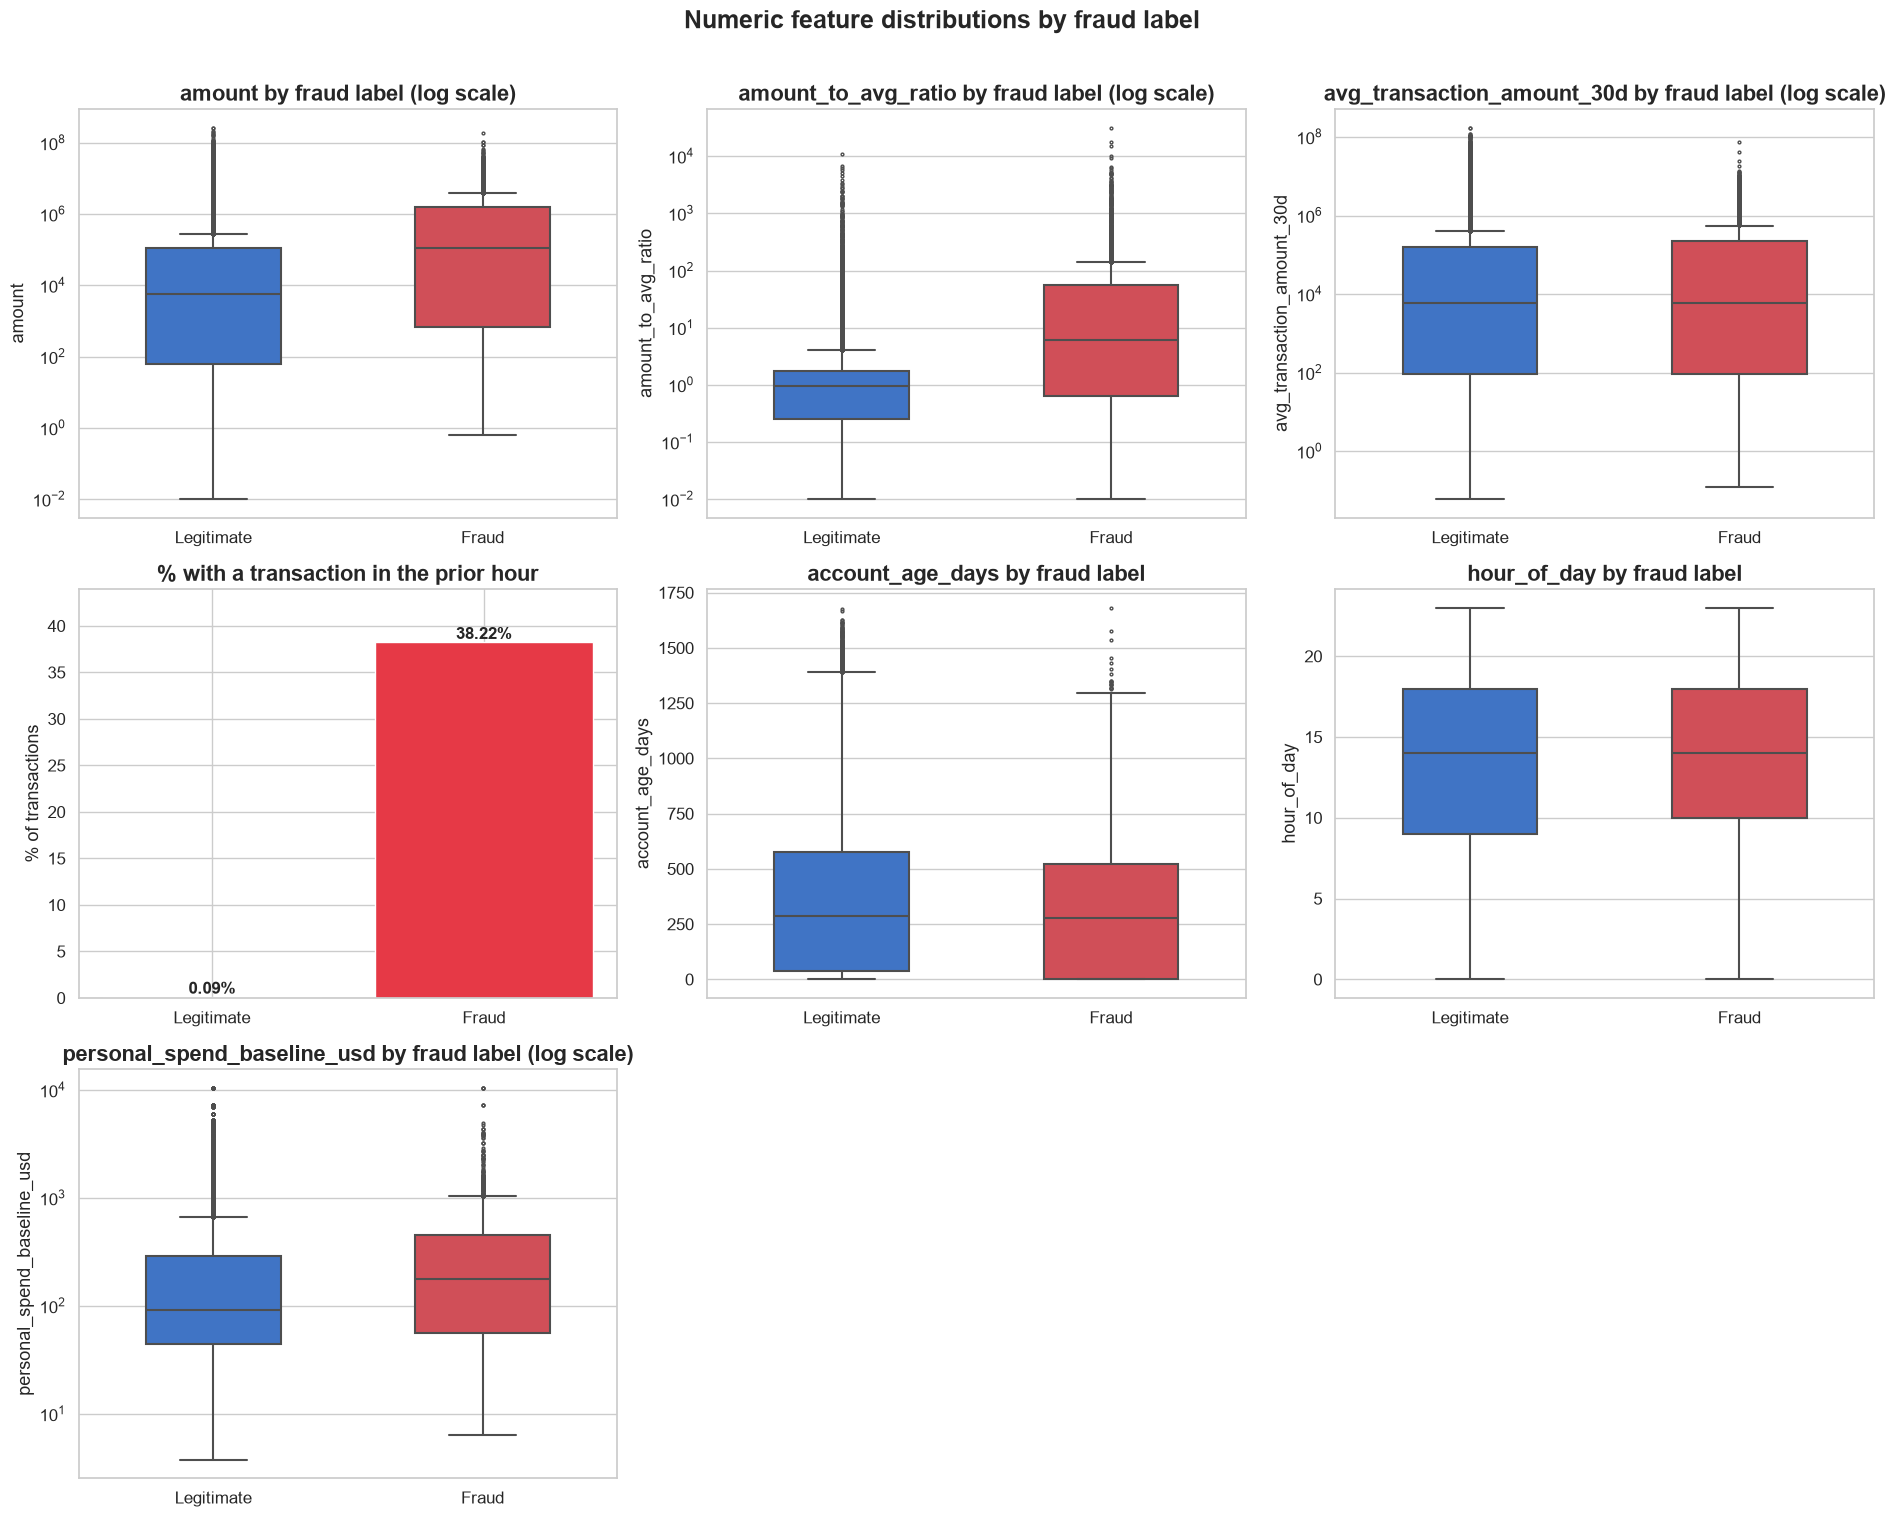

In [12]:
numeric_cols = [
    "amount", "amount_to_avg_ratio", "avg_transaction_amount_30d",
    "transaction_velocity_1h", "account_age_days", "hour_of_day",
    "personal_spend_baseline_usd",
]
log_scale_cols = {"amount", "amount_to_avg_ratio", "avg_transaction_amount_30d", "personal_spend_baseline_usd"}

fig, axes = plt.subplots(3, 3, figsize=(19, 15))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    if col == "transaction_velocity_1h":
        stat = df.groupby("is_fraud")[col].apply(lambda s: (s >= 1).mean()) * 100
        values, labels = [stat[0], stat[1]], [f"{stat[0]:.2f}%", f"{stat[1]:.2f}%"]
        bars = ax.bar(["Legitimate", "Fraud"], values, color=[LEGIT, FRAUD])
        for bar, label in zip(bars, labels):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), label,
                    ha="center", va="bottom", fontweight="bold", fontsize=12)
        ax.set_title("% with a transaction in the prior hour")
        ax.set_ylabel("% of transactions")
        ax.margins(y=0.15)
    else:
        use_log = col in log_scale_cols
        plot_df = df[[col, "is_fraud"]]
        if use_log:
            plot_df = plot_df[plot_df[col] > 0]

        sns.boxplot(
            data=plot_df, x="is_fraud", y=col, hue="is_fraud", ax=ax,
            palette={0: LEGIT, 1: FRAUD}, legend=False,
            width=0.5, fliersize=2, linewidth=1.5,
        )
        if use_log:
            ax.set_yscale("log")
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Legitimate", "Fraud"])
        ax.set_xlabel("")
        ax.set_ylabel(col)
        ax.set_title(f"{col} by fraud label" + (" (log scale)" if use_log else ""))
    ax.tick_params(labelsize=12)

for ax in axes[len(numeric_cols):]:
    ax.axis("off")

fig.suptitle("Numeric feature distributions by fraud label", fontweight="bold", fontsize=18, y=1.01)
plt.tight_layout()
plt.show()

**Findings:**
- `amount` and `amount_to_avg_ratio` show the clearest separation: fraud's median `amount` is roughly 20x legitimate's, and its median `amount_to_avg_ratio` (~6x an account's own average) is far above legitimate's (~1x, i.e. a typical transaction for that account) -- fraud is both larger in absolute terms and far more anomalous relative to the account's own history.
- `avg_transaction_amount_30d`, `account_age_days`, `hour_of_day`, and `personal_spend_baseline_usd` all show heavily overlapping boxes -- none of these separates the classes well on its own.
- `transaction_velocity_1h` has the widest gap of any numeric feature: **38.22% of fraud transactions have another transaction on the same account within the prior hour, vs. just 0.09% of legitimate ones** -- a >400x gap.

In [13]:
dist_summary = df.groupby("is_fraud")[["amount", "amount_to_avg_ratio", "avg_transaction_amount_30d",
                                           "account_age_days", "personal_spend_baseline_usd"]].median()
dist_summary.index = ["Legitimate", "Fraud"]
dist_summary

,amount,amount_to_avg_ratio,avg_transaction_amount_30d,account_age_days,personal_spend_baseline_usd
Legitimate,5511.62,0.95,5942.24,289.0,90.92
Fraud,107175.72,6.04,5942.24,276.0,178.99


## 7. Data-quality flag vs. target

`has_invalid_amount` (from the cleaning notebook) marks rows with a negative
`amount` or `avg_transaction_amount_30d` -- physically invalid for a
transaction-amount field, most likely refunds encoded as negative amounts
rather than a true data error.

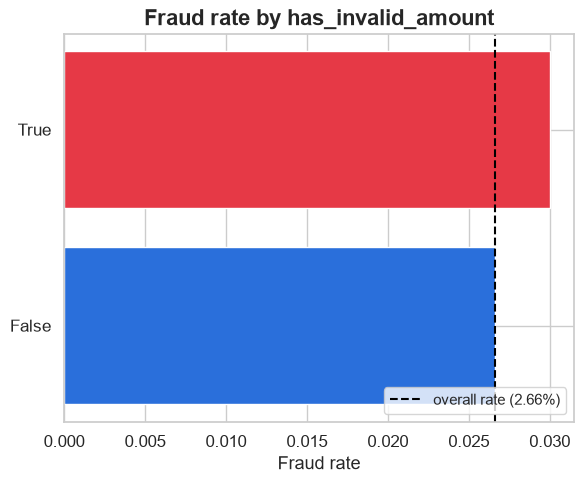

,fraud_rate,count
has_invalid_amount,,
True,0.030000,400
False,0.026592,125600


In [14]:
fig, ax = plt.subplots(figsize=(6, 5))
grp = plot_fraud_rate("has_invalid_amount", ax)
ax.set_title("Fraud rate by has_invalid_amount")
plt.tight_layout()
plt.show()
grp

**Finding:** fraud rate on flagged rows is close to the overall rate -- the
negative-amount rows don't skew toward fraud, consistent with them being
ordinary refunds rather than a distinct risk pattern.

## 8. Time-based view

`timestamp` on its own has too many unique values (125,758) to plot directly,
but a derived `month` captures whether fraud risk drifts across the year the
data covers.

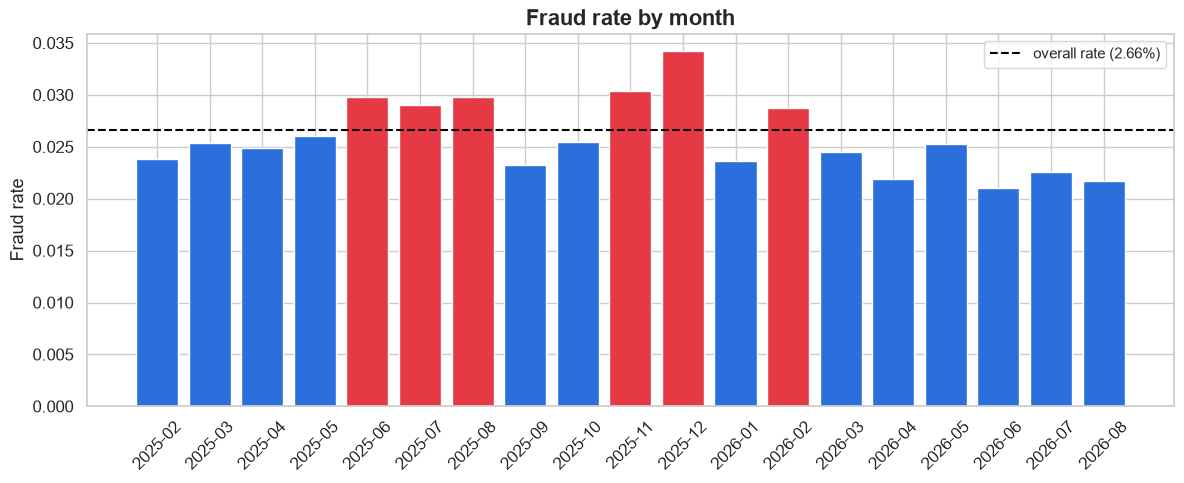

In [15]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["month"] = df["timestamp"].dt.to_period("M").astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
rates = df.groupby("month")["is_fraud"].mean()
colors = [FRAUD if v >= fraud_rate else LEGIT for v in rates.values]
ax.bar(rates.index.astype(str), rates.values, color=colors)
ax.axhline(fraud_rate, color="black", linestyle="--", linewidth=1.5, label=f"overall rate ({fraud_rate:.2%})")
ax.set_title("Fraud rate by month")
ax.set_ylabel("Fraud rate")
ax.tick_params(axis="x", rotation=45, labelsize=12)
ax.tick_params(axis="y", labelsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

**Finding:** fraud rate fluctuates month to month without a clear upward or
downward trend across the period covered -- no evidence of the fraud rate
drifting over time in this dataset.

## 9. Correlation matrix (numeric features + target)

Pearson correlation across the numeric features that would feed a model, plus
`is_fraud` itself, on a bold blue-to-red diverging scale centered at 0.

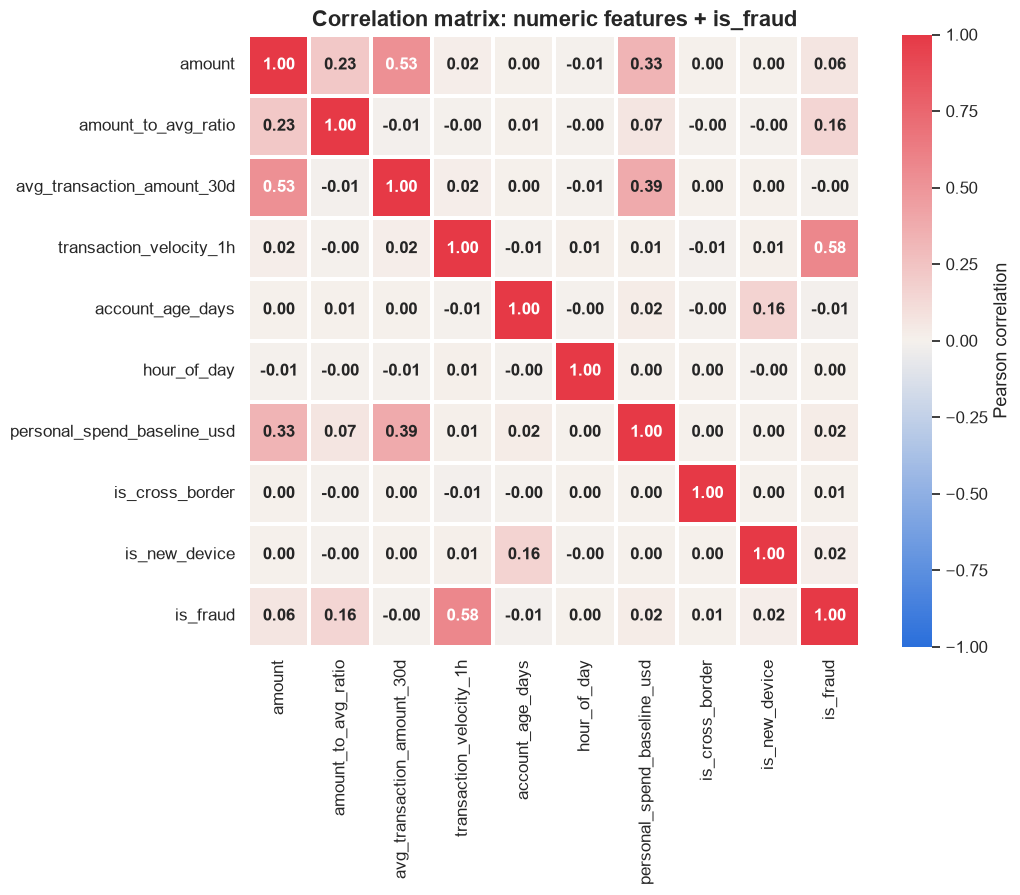

transaction_velocity_1h        0.577002
amount_to_avg_ratio            0.155231
amount                         0.063006
personal_spend_baseline_usd    0.024793
is_new_device                  0.021617
account_age_days              -0.013157
is_cross_border                0.006764
hour_of_day                    0.003477
avg_transaction_amount_30d    -0.001848
Name: is_fraud, dtype: float64

In [16]:
corr_cols = [
    "amount", "amount_to_avg_ratio", "avg_transaction_amount_30d", "transaction_velocity_1h",
    "account_age_days", "hour_of_day", "personal_spend_baseline_usd", "is_cross_border",
]
corr_df = df[corr_cols].copy()
corr_df["is_new_device"] = df["is_new_device"]
corr_df["is_fraud"] = df["is_fraud"]
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap=DIVERGING_CMAP, center=0, vmin=-1, vmax=1,
    linewidths=1.5, linecolor="white", square=True, ax=ax,
    annot_kws={"fontweight": "bold", "fontsize": 12},
    cbar_kws={"label": "Pearson correlation"},
)
ax.set_title("Correlation matrix: numeric features + is_fraud")
ax.tick_params(labelsize=12)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.set_label("Pearson correlation", fontsize=13)
plt.tight_layout()
plt.show()

corr["is_fraud"].drop("is_fraud").sort_values(key=abs, ascending=False)

**Findings:**
- `transaction_velocity_1h` dominates the numeric correlations with `is_fraud` (r = 0.58) -- far ahead of every other numeric feature -- followed by `amount_to_avg_ratio` (r = 0.16) and `amount` (r = 0.06). `is_new_device` and `personal_spend_baseline_usd` trail at r = 0.02 each -- weaker in linear correlation terms than the categorical fraud-rate split in Section 4 suggested, since a Pearson correlation only captures a straight-line relationship.
- No problematic multicollinearity among the numeric features -- the strongest pairwise correlation is `amount` vs. `avg_transaction_amount_30d` (r = 0.53), expected since both measure spend scale, and nothing crosses into redundant (r > 0.8) territory.

## 10. Summary of findings

- **Target is heavily imbalanced**: 2.66% fraud rate -- accuracy is meaningless here; PR-AUC / recall-based thresholds are the right call for modeling.
- **`transaction_velocity_1h` is the single strongest signal** in the dataset by a wide margin (r = 0.58; a >400x gap in "repeat transaction within the hour" rate between classes).
- **`amount_to_avg_ratio` and `amount`** are the next-strongest numeric signals -- fraud transactions are both larger and far more anomalous relative to the account's own history.
- **Categorical risk is concentrated in a few segments**: Wire Transfer / Crypto Exchange merchant categories, Business accounts, low KYC tiers, new devices, and cross-border transactions all run meaningfully hotter than the 2.66% baseline.
- **Weak/no signal**: `day_of_week`, `currency` (redundant with `home_country`), `transaction_country`/`home_country`, `account_age_days`, `avg_transaction_amount_30d`, `personal_spend_baseline_usd`, `hour_of_day`, and month-over-month time trend.
- **`status` must be excluded from modeling** -- it is a leakage risk, not a genuine predictive feature.
- **Data quality**: ~0.3% of rows carry a negative `amount`/`avg_transaction_amount_30d` (flagged via `has_invalid_amount` in the cleaning notebook); these do not skew toward fraud and are consistent with ordinary refunds.
